# 解說
這一篇承襲20260225Feb_code資料夾裡的 "OU_NoTrain-2D Spiral_betaSigmaConst" 這一篇。  
1. 先試試看 Training的時候仍然是用$L_{DSM}$，但可以算算看$I_{DSM}(\theta)$ (output仍然是$\theta$)
2. **驗證指標:** 如果算出來的值接近**0**, 就代表效果好。

# Model

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def sample_p0_mix(n_points=2500):
    theta = np.sqrt(np.random.rand(n_points)) * 6 * np.pi # 角度
    r = 1 * theta 
    
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    data = np.stack([x, y], axis=1) + np.random.randn(n_points, 2) * 0.1
    return data

In [42]:
beta = 10.0   #<<<<<<<<<<<<<<<<<<<
sigma = 5.0
t = 1.0
x0 = sample_p0_mix(n_points=2500)

mu_t = np.exp(-beta * t) * x0
var_t = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
std_t = np.sqrt(var_t)
xt = mu_t + std_t * np.random.randn(*x0.shape)


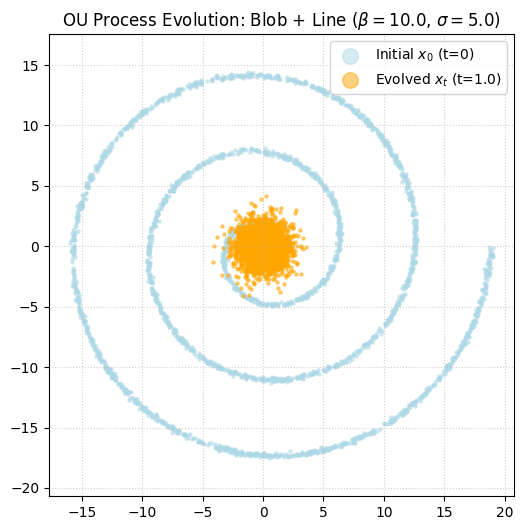

In [43]:
plt.figure(figsize=(6,6))
plt.scatter(x0[:, 0], x0[:, 1], color='lightblue', s=5, alpha=0.5, label='Initial $x_0$ (t=0)')
plt.scatter(xt[:, 0], xt[:, 1], color='orange', s=5, alpha=0.5, label=f'Evolved $x_t$ (t={t})')

plt.title(fr'OU Process Evolution: Blob + Line ($\beta={beta}$, $\sigma={sigma}$)')
plt.legend(markerscale=5)
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 256), 
            nn.SiLU(), 
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x, t):
        t_input = t.view(-1, 1).expand(x.shape[0], 1)
        return self.net(torch.cat([x, t_input], dim=-1))

In [45]:
def train(model, beta, sigma, T, steps):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    loss_his=[]
    iDsm_his=[]

    for i in range(steps):
        x0_np = sample_p0_mix(n_points=2500)
        x0 = torch.tensor(x0_np, dtype=torch.float32)
        t = torch.rand(x0.shape[0]) * T
        mu_t = torch.exp(-beta * t).view(-1, 1) * x0
        std_t = torch.sqrt((sigma**2 / (2*beta)) * (1 - torch.exp(-2*beta*t))).view(-1, 1)
        eps = torch.randn_like(x0)
        xt = mu_t + std_t * eps
        
        optimizer.zero_grad()
        eps_pred = model(xt, t)
        loss = nn.MSELoss()(eps_pred, eps)
        loss.backward()
        optimizer.step()
        
        # <<<<<<<<<<<<<<<<<< I_dsm indecator
        with torch.no_grad():
            inner_product = torch.sum(eps_pred * (eps_pred - eps), dim=1)
            i_dsm_batch = torch.mean(inner_product / sigma**2)

        loss_his.append(loss.item())
        iDsm_his.append(i_dsm_batch.item())
        if i % 50 == 0:
            print(f"Step {i}, Loss: {loss.item():.4f}, Indicator (Idsm): {i_dsm_batch.item():.4f}")
    return loss_his, iDsm_his

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ScoreNet().to(device)

print("Starting training of Score Model...")
T=t
steps=10000
loss_history, idsm_history = train(model, beta=beta, sigma=5.0, T=T, steps=steps)


Starting training of Score Model...
Step 0, Loss: 0.9876, Indicator (Idsm): -0.0002
Step 50, Loss: 0.3077, Indicator (Idsm): -0.0005
Step 100, Loss: 0.2810, Indicator (Idsm): 0.0023
Step 150, Loss: 0.2489, Indicator (Idsm): -0.0016
Step 200, Loss: 0.2392, Indicator (Idsm): 0.0012
Step 250, Loss: 0.2439, Indicator (Idsm): 0.0012
Step 300, Loss: 0.2260, Indicator (Idsm): 0.0003
Step 350, Loss: 0.2231, Indicator (Idsm): 0.0004
Step 400, Loss: 0.2390, Indicator (Idsm): 0.0020
Step 450, Loss: 0.2083, Indicator (Idsm): -0.0001
Step 500, Loss: 0.2235, Indicator (Idsm): -0.0014
Step 550, Loss: 0.2239, Indicator (Idsm): 0.0007
Step 600, Loss: 0.2350, Indicator (Idsm): 0.0000
Step 650, Loss: 0.2220, Indicator (Idsm): 0.0008
Step 700, Loss: 0.2172, Indicator (Idsm): 0.0003
Step 750, Loss: 0.2150, Indicator (Idsm): -0.0008
Step 800, Loss: 0.2404, Indicator (Idsm): 0.0013
Step 850, Loss: 0.2196, Indicator (Idsm): -0.0008
Step 900, Loss: 0.2039, Indicator (Idsm): -0.0011
Step 950, Loss: 0.2188, Indi

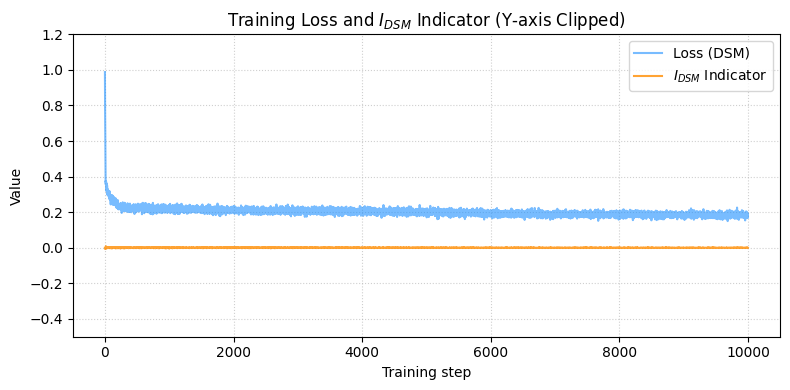

In [47]:
def plot_loss_curve(loss_list, idsm_list):
    plt.figure(figsize=(8,4))
    
    plt.plot(loss_list, linewidth=1.5, label="Loss (DSM)", color="dodgerblue", alpha=0.6)
    plt.plot(idsm_list, linewidth=1.5, label="$I_{DSM}$ Indicator", color="darkorange", alpha=0.8)
    
    plt.xlabel("Training step")
    plt.ylabel("Value")
    plt.title("Training Loss and $I_{DSM}$ Indicator (Y-axis Clipped)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    plt.ylim(-0.5, 1.2)  
    
    plt.tight_layout()
    plt.show()
plot_loss_curve(loss_history, idsm_history)

# Reverse

In [48]:
@torch.no_grad()
def reverse_sample(model, n_samples, beta, sigma, T, dt):
    device = next(model.parameters()).device
    var_T = sigma**2 / (2 * beta)
    x = torch.randn(n_samples, 2).to(device) * np.sqrt(var_T)
    
    ts = np.arange(T, 0, -dt)
    for t_val in ts:
        t_tensor = torch.full((n_samples,), t_val).to(device)
        eps_pred = model(x, t_tensor)
        sigma_t = torch.sqrt((sigma**2 / (2 * beta)) * (1 - torch.exp(torch.tensor(-2 * beta * t_val))))
        score = -eps_pred / (sigma_t + 1e-5)
        
        drift = -beta * x - (sigma**2) * score
        noise = torch.randn_like(x) if t_val > dt else 0
        
        x = x - drift * dt + sigma * np.sqrt(dt) * noise
        
    return x

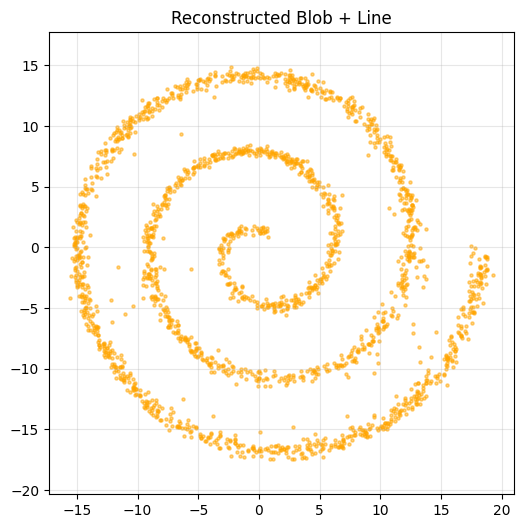

In [49]:
dt=T/steps
generated_data = reverse_sample(model, n_samples=2000, beta=beta, sigma=5.0, T=T, dt=dt)
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
samples = generated_data.cpu().numpy()
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=5, color='orange')
plt.title("Reconstructed Blob + Line")
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

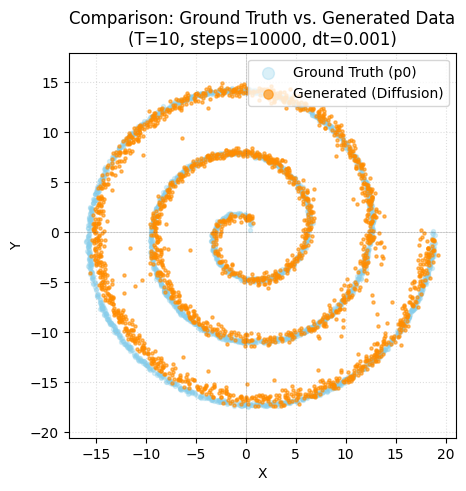

In [50]:
gt_data = sample_p0_mix(n_points=2500)
if isinstance(gt_data, torch.Tensor):
    gt_data = gt_data.cpu().numpy()

gen_data = generated_data.cpu().numpy()
plt.figure(figsize=(5, 5))
plt.scatter(gt_data[:, 0], gt_data[:, 1], 
            color='skyblue', s=8, alpha=0.3, label='Ground Truth (p0)')
plt.scatter(gen_data[:, 0], gen_data[:, 1], 
            color='darkorange', s=5, alpha=0.6, label='Generated (Diffusion)')
plt.axhline(0, color='black', lw=0.5, alpha=0.2)
plt.axvline(0, color='black', lw=0.5, alpha=0.2)
T=10             ##########><<<<<<<<<<<<<<
steps=10000
plt.title(f"Comparison: Ground Truth vs. Generated Data\n(T={T}, steps={steps}, dt={T/steps:.3f})")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(markerscale=3)
plt.axis('equal') 
plt.grid(True, linestyle=':', alpha=0.4)

plt.show()

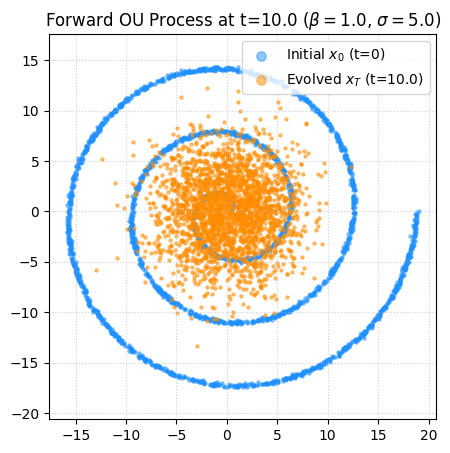

In [51]:
x0 = sample_p0_mix(n_points=2500)

beta = 1.0
sigma = 5.0
T = 10.0
mu_T = x0 * np.exp(-beta * T)
std_T = np.sqrt((sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * T)))

xT = mu_T + std_T * np.random.randn(*x0.shape)

plt.figure(figsize=(5,5))
plt.scatter(x0[:, 0], x0[:, 1], s=5, alpha=0.5, color='dodgerblue', label='Initial $x_0$ (t=0)')
plt.scatter(xT[:, 0], xT[:, 1], s=5, alpha=0.5, color='darkorange', label=f'Evolved $x_T$ (t={T})')

plt.title(fr"Forward OU Process at t={T} ($\beta={beta}$, $\sigma={sigma}$)")
plt.legend(markerscale=3)
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()